# Introducción al mundo _deep_: herramientas

Durante este cuadernillo veremos la herramienta principal que usaremos para interactuar con el mundo _deep_: ```FastAI```.

[```FastAI```](https://docs.fast.ai/) es una librería de **alto nivel** que permite interactuar con el mundo _deep_ de una forma amistosa. Está construida sobre [```TensorFlow```](https://www.tensorflow.org/?hl=es-419), una librería un tanto menos amigable. Para que te hagas una idea, ```TensorFlow``` está al nivel de ```numpy``` y ```FastAI``` al nivel de ```sklearn```.

```FastAI``` no es la única librería que permite trabajar de forma sencilla con arquitecturas _deep_, también tenemos otras muy famosas como lo son [```Keras```](https://keras.io/) o las librerías de _transformers_ de [```HuggingFace```](https://huggingface.co/).

Todas estas librerías, además de librerías, han creado sus propias comunidades, por lo que es bastante común referirse a ellas como tal. Por ejemplo, la comunidad de ```HuggingFace``` tiene un propio [ChatGPT](https://huggingface.co/chat/).

# **_Deep Learning_**

Metiéndonos en el asunto deberíamos responder: **¿qué es el _deep learning_?**

Hasta ahora hemos visto qué era el **Machine Learning** (aprendizaje automático): un conjunto de algoritmos que permitían extraer información general a partir de unos datos y solventar, posteriormente, ciertas tareas (agrupación, clasificación, regresión...). El **Deep Learning** está dentro también de esta categoría, solo que un tipo de herramienta muy concreto para resolver las tareas: las **redes neuronales profundas**.

Mientras que las redes neuronales que hemos visto en el Tema 4 podían tener algunas (decenas, quizá) capas ocultas, las **redes neuronales profundas** (DNN; _deep neural network_) pueden tener decenas, centenas o miles de capas ocultas. Ésto tiene varias implicaciones sobre el modelo, la más inmediata es que necesita muchísimos más datos, tiempo y recursos (_hardware_) para poder funcionar. Realmente, esto no tendría ninguna ventaja directa sobre nuestra tarea (salvo las que ya hemos visto en el Tema 4).

Lo que marcó realmente la diferencia fue la llegada de las **redes neuronales convolucionales** (**CNN**; _convolutional neural networks_). Estas redes agrupan sus neuronas en capas convolucionales (no son _filas_, sino _hipercubos_). Aplicando distintas capas convolucionales (que veremos a continuación), el modelo es capaz de detectar patrones cada vez más complejos: primero puede detectar formas geométricas sencillas, como círculos o triángulos; y puede acabar detectando objetos muy complejos, como animales enteros.

La forma de trabajar con una CNN suele ser bastante común: primero se construye un **codificador** que permite obtener una representación **muy reducida**, llamada **mapa de características** (_feature map_), de la entrada del modelo (que generalmente suele ser una imagen); posteriormente, se trabaja con el mapa de características. Si se desea obtener una categoría (clasificación), se añade una componente completamente conectada (como las del Tema 4), cuya entrada será el propio mapa de características; si se desea obtener otra imagen, se añade una componente **decodificador**, que es capaz de construir imágenes a partir de un **mapa de características**, etcétera.



## Sobre el **mapa de características**: arquitecturas _deep learning_ y _backbones_

Como obtener un **mapa de características** adecuado es una tarea muy común y muy importante en cualquier tarea _deep_, es también muy común hacer uso de codificadores preentrenados. Por ejemplo, para trabajar con imágenes, es muy común utilizar modelos que se hayan preentrenado con la base de datos de [ImageNet](https://www.image-net.org/), que posee más de 14 millones de imágenes de todo tipo.

Por esta razón, los codificadores suelen llamarse también **arquitecturas** (porque pueden construirse de distintas formas modificando las capas internas que tienen). Por ello, es muy común decir que "se ha usado un resnet18" si la arquitectura que utiliza tu modelo hace uso del codificador preentrenado que se usó en el modelo [ResNet-18](https://es.mathworks.com/help/deeplearning/ref/resnet18.html). Realmente, ResNet es una familia entera de codificadores, la versión "18" hace referencia a su tamaño (es la más pequeña), existen otras muchas versiones (34, 50, 101...).

Es muy importante que visualices lo que acabamos de comentar en el párrafo anterior, así que lo vamos a volver a repetir:
- Se crea un **modelo general**, con una arquitectura específica (ciertas capas en cierto orden) y se entrena usando millones de datos de bases de datos muy generales, como ImageNet.
- Se **rompe** el modelo general en partes pequeñas y se extrae el **codificador**, la componente que nos permite obtener el **mapa de características** (en este caso de una imagen) a partir del dato completo. El **mapa de características** es una representación muy reducida y manejable del dato original.
- Se crea **otro modelo**, generalmente de caracter más específico (el modelo original había visto millones de imágenes, pero nos queremos centrar solo en algunas particulares, por ejemplo: en clasificar gatos y perros). Este modelo utilizará el **mismo codificador (arquitectura)** que el **modelo general**.
- Se **entrena** o **reentrena** la arquitectura original. Si se entrena desde cero, puede ser un proceso muy costo; si se reentrena, se estará aplicando una técnica llamada **fine tuning** y no se estará utilizando solo la **arquitectura** del modelo general, sino que también se estará usando su **backbone**, su esqueleto, los **pesos finales** de su entrenamiento. Este proceso de **fine tuning** permite, a día de hoy, crear modelos muy buenos con muy pocos datos (reutilizando lo que ya se ha entrenado).
- Se utiliza el **modelo reentrenado** para hacer inferencia sobre nuevos datos.

## Capas convolucionales

Hace un rato hemos comentado las **capas convolucionales**. Hemos dejado caer que las arquitecturas CNN eran superiores a las DNN, dado que las primeras agrupaban sus neuronas de formas especiales: en capas. De hecho, esta distribución es la que daba nombre, después, a las **arquitecturas** usadas en los distintos modelos.

La ventaja principal de agrupar las neuronas en capas en vez de usarlas en una red completamente conectada está relacionada con el tipo de dato de entrada que solemos tener en las tareas de _deep learning_: imágenes, textos... Son tipos de datos **enormes** para ser tratados por redes neuronales clásicas. Por ejemplo, una imagen de 10x10 (fíjate qué resolución) necesitaría ser aplanada para poder ser introducida en una red neuronal con 100 neuronas en su capa de entrada. Además, al aplanar la imagen, estaríamos separando los píxeles que originalmente se encontraban unidos. Las CNN no necesitan aplanar la imágen, simplemente aplican **filtros** a ésta, permitiendo generar subgrupos de imágenes que se fijan en la imagen a distintas _distancias_. Básicamente, es como coger una imagen, una lupa e incidir en las partes que realmente te importan.

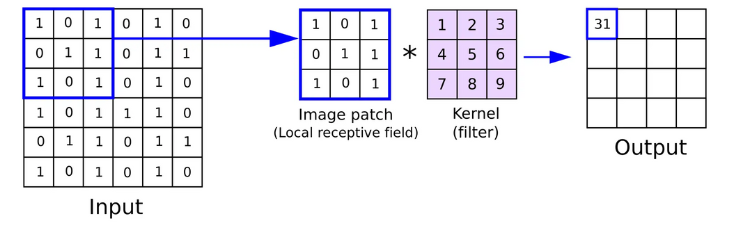

La elección de los números del filtro (en la imagen, la parte sombreada) es justamente lo que tiene que aprender la red.

Cada **kernel** (o filtro) tiene un tamaño (1x1, 3x3, 5x5...) y un desplazamiento (**stride**). El tamaño determina cuántos píxeles es capaz de ver a la vez, mientras que el desplazamiento define lo rápido que avanza por la imagen.

El resultado final, es un conjunto de _outputs_ (uno para cada filtro aplicado), que se combina creando un mapa de características parcial que, muy posiblemente, sea la entrada de otra capa de la CNN.

En general, existen cuatro tipos de capas **fundamentales** dentro de las CNN. Nada impide crear combinaciones de éstas:
- Capas **convolucionales**. Son el núcleo principal de las CNN. A través de estas capas se aplican distintos **filtros** (_kernels_) a las imágenes y se obtienen versiones reducidas que son capaces de detectar patrones en la imagen original.
- Capas de **_pooling_**. Permiten reducir el tamaño de la entrada **sin aplicar filtros**. También tienen un tamaño y desplazamiento determinados. Son la versión **estática** de las **capas convolucionales**.Se suelen aplicar uno de dos tipos:
  - **Max pooling**. Reduce un grupo de valores a su máximo.
  - **Average pooling**. Reduce un grupo de valores a su media.
- Capas de **activación**. Funcionan de la misma forma de la que funcionaban las funciones de activación de las DNN, solo que están pensadas para activar capas enteras del mapa de características. Realmente, son las funciones de activación aplicadas con un ```kernel``` 1x1 y un desplazamiento de 1 (para cada pixel, en el fondo).
- Capas **completamente conectadas**. Se utilizan en los problemas que requieren utilizar todo el espacio latente para dar una salida textual o numérica. Por ejemplo, se usan en los problemas de clasificación o detección.

Realmente, conociendo lo anterior y usando ```TensorFlow``` puedes crear tus propios modelos. Sin embargo, esta parte _manual_ de creación de modelos nos llevaría más tiempo del que disponemos en el curso, por lo que, salvo que sea estrictamente necesario, utilizaremos modelos ya creados (es decir, **arquitecturas**).

# **_FastAI_**

Hay muchas formas diferentes de trabajar con ```FastAI```. Utilizando todos los avances de la comunidad, se pueden realizar casi todas las tareas del mundo _deep_ desde esta librería.

Si bien es cierto que existe una forma sencilla de trabajar mediante factorías, aquí veremos una forma intermedia, que nos va a permitir diseñar y configurar más detalles de nuestros datos.

Para afrontar una tarea de _deep learning_ vamos a necesitar, **siempre**, satisfacer tres necesidades: los **datos**, la información con la que entrenaremos nuestro modelo; la **arquitectura** y el **backbone** de nuestro modelo; y nuestro objetivo.

A partir de ahora nos meteremos en barro. Ten en cuenta que, como vamos a hacer uso de **redes neuronales profundas**, realizaremos operaciones con un peso computacional muy elevado que podrían beneficiarse del uso de una **GPU**. Asegúrate de tenerla configurada (```Entorno de ejecución``` -> ```Cambiar tipo de entorno de ejecución``` -> ```T4 GPU```).

Si tienes disponibles unidades de computación (Google Colab Pro), actívala desde ```Conectar``` -> ```Ver recursos```.

# Un ejemplo real

En nuestro primer ejemplo vamos a realizar el _hola mundo_ del _deep learning_. A partir de varias imágenes de gatos y perros, vamos a crear un **clasificador de imágenes** que nos permitirá determinar si en la imagen aparece un gato o un perro. Intenta no quedarte solo en el ejemplo y ver _más allá_ de las posibilidades que trae este tipo de herramientas.

Lo primero que vamos a hacer es actualizar ```FastAI```, necesitamos la última versión.

In [ ]:
!pip install -Uqqq fastai
!pip install fastprogress==1.0.3 # 08/02/2026: esta librería se ha actualizado. Hasta que FASTAI se actualice, tenemos que usar la versión anterior

  Attempting uninstall: fastprogress
    Found existing installation: fastprogress 1.1.3
    Uninstalling fastprogress-1.1.3:
      Successfully uninstalled fastprogress-1.1.3


Ahora, lo importamos.

Por ahora lo voy a importar todo. No es una buena praxis, pero nos servirá al principio hasta que sepamos exáctamente qué hace cada objeto dentro de ```FastAI```.

In [ ]:
from fastai.vision.all import *

random_seed = 33

## Obteniendo los datos

Nuestros datos los podremos obtener de cualquier sitio que conozcas y que puedas descargar o clonar en Google Colab. Lo más típico es usar grandes repositorios de datos, como GitHub, Kaggle o los HuggingFace - spaces.

En este ejemplo, usaremos una versión reducida (muy reducida) de [este conjunto de datos](https://www.kaggle.com/datasets/tongpython/cat-and-dog?resource=download) de Kaggle. Puedes descargarlo desde [este enlace](https://1drv.ms/u/s!AnwCeLpBkSdgaVi1LlBZ5tuKZek) o usar la librería de kagglehub para instalarlo.

Para poder trabajar con él de forma adecuada, necesitamos que tenga una estructura común de la forma:
- dataset
  - train
    - cat
    - dog
  - test
    - cat
    - dog

Esto es común en todos los problemas, si tuviésemos más clases, se añadirían más subcarpetas dentro de ```train``` y ```test```, si tuviésemos imágenes sin etiquetas y necesitásemos aplicar aprendizaje semisupervisado, añadiríamos una subcarpeta al nivel de ```train``` llamada ```unlabelled```.

In [ ]:
import kagglehub

# Download latest version
dataset_path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Path to dataset files:", dataset_path)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Path to dataset files: /kaggle/input/cat-and-dog


In [ ]:
!ls /root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1

ls: cannot access '/root/.cache/kagglehub/datasets/tongpython/cat-and-dog/versions/1': No such file or directory


Voy a crear algunas variables para poder acceder de forma sencilla a las rutas de estas carpetas.

In [ ]:
test_path = dataset_path + "/test_set"
train_path = dataset_path + "/training_set"

## Cargando los datos

Para poder alimentar nuestro modelo con toda esta información, necesitamos "cargarla" de alguna forma que el modelo pueda entenderla. Para ello, usaremos un objeto que establece dicha comunicación. Este objeto es **muy importante** al trabajar con ```FastAI``` y se llama ```DataBlock```.

Un ```DataBlock``` define un bloque de datos a partir del cual se podrá crear un "cargador de datos" (llamado ```DataLoader```). Veamos cómo se puede definir:

In [ ]:
db = DataBlock(
    blocks=(ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = RandomSplitter(valid_pct=0.2, seed=random_seed),
    get_y = parent_label,
    item_tfms = [Resize(256)]
)

En la celda anterior, hemos creado un ```DataLoader``` con los siguientes parámetros:
- ```blocks```. Determina los bloques de la red. En este caso, el primer bloque que recibe la red es de tipo ```ImageBlock``` (recibe una imagen), mientras que el último (el que devuelve) es de tipo ```CategoryBlock```, es decir, una categoría.
- ```get_items```. Es una **función** que recibirá como parámetro el _path_ del _dataset_ y que podrá construir una L-list (una especie de lista con índices explícitos).
- ```splitter```. Es un objeto parecido a los que vimos de ```kfold``` y derivados en el tema 4. Nos permite separar los datos en conjuntos de entrenamiento y testeo. En este caso, separamos los datos en un 80 - 20.
- ```get_y```. Es una **función** que permite obtener la etiqueta del dato a partir del propio dato. En este caso, obtenemos la etiqueta de cada caso a partir del _parent\_label_, es decir, de la carpeta en la que se cuentra.
- ```item_tfms```. Es una lista de transformaciones (preprocesamiento) que se les debe hacer a los datos antes de trabajar con ellos. Uno de los requisitos para poder introducirlos en la red es que tengan el mismo tamaño, así que aplicamos una transformación ```Resize``` que nos permite convertir todas las fotos en tamaño 256x256.

Hay muchísimas situaciones diferentes para las que aplicaremos aquí disintos parámetros; además, la mayoría de errores posteriores están directamente asociados a una mala creación del ```DataBlock```. No te preocupes, lo irás viendo poco a poco.

Una vez creado el ```DataBlock``` podemos crear su ```DataLoader``` asociado. Fíjate que le paso la ruta de las imágenes de entrenamiento, si le pasase la ruta del _dataset_, las recogería todas (lo hace de forma recursiva).

In [ ]:
dl = db.dataloaders(train_path)

Finalmente, podemos mostrar (te aconsejo hacer esto siempre para ver si ha podido cargarse toda la información correctamente) un pequeño ejemplo de cómo se ven nuestros datos.

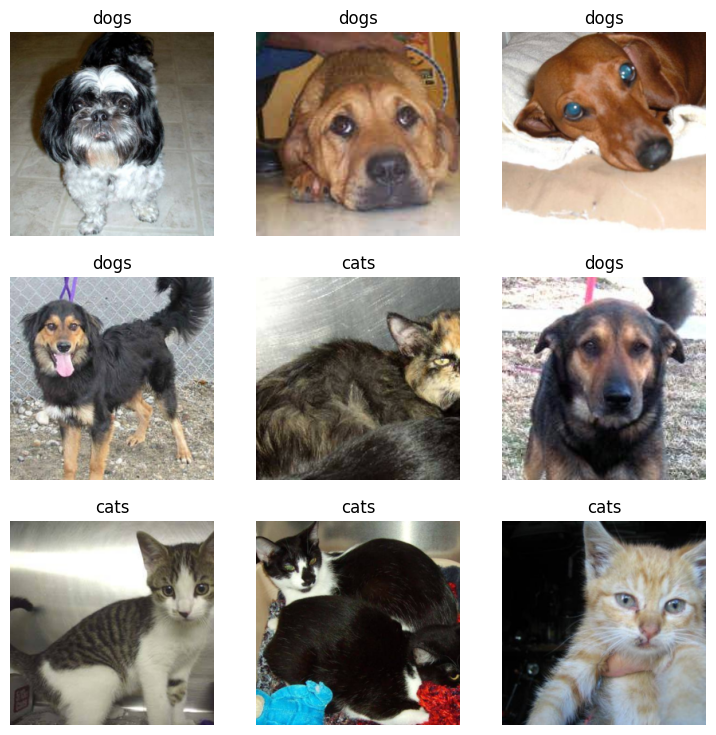

In [ ]:
dl.show_batch()

## Trabajando con los datos

Si la celda anterior muestra un resultado coherente, podemos comenzar a trabajar con nuestro primer modelo _deep_. Hay un montón de estrategias que no hemos aplicado y que perjudicarán al entrenamiento de este primer modelo, pero no te preocupes: las iremos viendo durante el tema.

Una vez creado el ```DataLoader``` podemos asociarlo con un modelo. El modelo que vamos a usar es uno de los más simples, un ```ResNet-18```. Al asociar los datos con el modelo, crearemos un objeto de tipo ```Learner```, que es el objeto utilizado por ```FastAI``` para entrenar el modelo.

In [ ]:
learner = vision_learner(dl, resnet18)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 208MB/s]


Lo que hemos hecho es descargar tanto la arquitectura (```ResNet-18```) como sus pesos asociados (el backbone).

Ahora, durante el entrenamiento, podremos ignorar el _backbone_ o aplicar la técnica de _fine\_tuning_, que nos permitirá aprovechar ese conocimiento adquirido, en este caso, de la base de datos de ImageNet. Veamos ambos casos.

### Entrenando desde cero (training from scratch)

Al entrenar desde cero, los pesos anteriores son ignorados en gran medida (realmente esto no es desde cero, pero es casi lo mismo).

Para entrenar el modelo, simplemente llamaremos a la función ```fit``` indicando el número de épocas que queremos entrenar, recuerda:
- Una época es el conjunto de todos los paquetes.
- Un paquete es un conjunto de datos reducido que el modelo ve de forma simultánea.

In [ ]:
learner.fit(5)

epoch,train_loss,valid_loss,time
0,0.122559,0.033726,00:54
1,0.060865,0.029282,00:34
2,0.047889,0.023007,00:34
3,0.036445,0.021840,00:34
4,0.029263,0.021366,00:35


Como tenemos solo 100 imágenes por clase, el entrenamiento es instantáneo. Te reto a intentar entrenar el mismo modelo pero con los datos reales (**ojo**, que tendrás que crear la estructura de carpetas que te he mostrado arriba), para que veas que no siempre es así.

Fíjate que la misma barra verde sube dos veces (vuelve a ejecutar la celda anterior si no te habías percatado):
- La primera vez marca el entrenamiento del modelo. Todos los datos de entrenamiento son separados en distintos _batches_ y mostrados al modelo, actualizando los pesos del mismo. Puedes ir viendo la métrica de entrenamiento.
- La segunda vez marca la validación del modelo. Todos los datos de validación son separados en distintos _batches_ y mostrados al modelo, calculando así la métrica de validación.

Como no hemos indicado ninguna métrica particular, lo que está haciendo es usar la _valid\_loss_, que es una métrica genérica.

Llegados a este punto, podrías preguntarte si realmente es útil la información que aprecias en la tabla. Realmente, con tan poca información, puedes obtener resultados útiles: si la métrica de entrenamiento sigue bajando mientras que la de validación comienza a subir o se estanca, significa que estás sobreentrenando a tu modelo. Veremos técnicas de ```EarlyStopping``` para evitarlo.

Cuando nuestro modelo está entrenado, podemos realizar validación e inferencia.

In [ ]:
learner.validate() # devuelve el valor de todas las métricas, muy útil cuando hay varias

[0.021365778520703316]

### Entrenando desde un _backbone_ (fine tuning)

Una de las estrategias más poderosas que tenemos a mano para entrenar nuestros modelos es el _fine tuning_.

Esta estrategia nos permite aprovechar los conocimientos aprendidos por un modelo miles de veces más grande que el nuestro en vez de tener que construirlo y entrenarlo nosotros mismos.

La forma de utilizarla es parecida a la que ya hemos visto, solo que tiene épocas congeladas. Una _freeze epoch_ es una época en la que algunos pesos de la red están congelados, es decir: **NO se actualizan**. Esto es extremadamente útil a la hora de reutilizar modelos. Recuerda que los modelos tenían dos partes diferenciadas (al menos los de clasificación, como el nuestro): el codificador y la capa completamente conectada. La capa completamente conectada es lo que nos interesa entrenar (y esto se hará desde cero), mientras que el codificador debería ser reutilizado del modelo previo. Para ello, lo que haremos será entrenar algunas épocas (un par, generalmente) nuestro nuevo modelo impidiendo que modifique los pesos de su modelo predecesor.

In [ ]:
learner = vision_learner(dl, resnet18) # lo volvemos a crear para que no reutilice lo del apartado anterior

In [ ]:
learner.fine_tune(3, freeze_epochs=2)

epoch,train_loss,valid_loss,time
0,0.179998,0.044649,00:35
1,0.115336,0.041587,00:35


epoch,train_loss,valid_loss,time
0,0.071253,0.035399,00:37
1,0.041909,0.023300,00:38
2,0.017567,0.021736,00:38


Puedes apreciar los cambios que implica haber hecho _fine\_tuning_. Como ves, obtenemos mejor métrica _valid\_loss_.

Ten en cuenta que esta estrategia puede verse eclipsada si la cantidad de datos es muy grande, porque el modelo que **no** la utiliza tendrá suficientes datos como para dar buenos resultados. En este ejemplo, con la misma cantidad (bastante pobre) de datos, logramos reducir a la mitad la métrica simplemente usando esta estrategia.

De igual forma, podemos validar nuestro modelo.

In [ ]:
learner.validate()

[0.02173631638288498]

Fíjate que conseguimos mejor puntuación al hacer _fine\_tuning_.

## Testeo

Al igual que con los modelos clásicos, podemos testear también nuestras redes _deep_.

Vamos a crear un ```DataLoader``` para agruparlos todos. Es muy común tener que modificar también el ```DataBlock```, porque pudieran existir transformaciones que no queramos aplicar a los nuevos datos. En este primer caso sencillo lo único que modificaremos será la cantidad de datos que queremos en el conjunto de validación.

Este proceso puede hacerse de muchas formas, esta es la más sencilla, pero veremos otras más adelante.

In [ ]:
db = DataBlock(
    blocks = (ImageBlock, CategoryBlock),
    get_items = get_image_files,
    splitter = None, # no quiero dividir mis datos: úsalos todos
    get_y = parent_label,
    item_tfms = [Resize(256)]
)

In [ ]:
dl = db.dataloaders(test_path, bs=50)

In [ ]:
learner.dls = dl # modifico el dataloader, la forma que tiene de recoger los datos

In [ ]:
learner.validate() # valido utilizando los nuevos datos (bueno, un 99% de ellos)

[0.12963008880615234]

Fíjate que la métrica es ligeramente superior a la de entrenamiento y validación (respecto a la última estrategia que hemos utilizado).

# Resumen

Durante este cuadernillo inicial hemos podido explicar los conceptos más básicos que serán necesarios a lo largo del tema 5. No dudes en ejecutar las celdas, entender sus mecanismos y preguntar todas las dudas que tengas: todo lo visto aquí aumentará en el futuro.